In [1]:
# ============================================================
# CELL 1 — Imports & Load Clean Data
# ============================================================
# WHAT THIS DOES:
#   Loads clean.parquet from notebook 02 and sets up paths.
#   Also defines constants for the strategy parameters.
#
# WHAT YOU SHOULD SEE:
#   Shape matching notebook 02 output (844K+ rows, 24 cols).
# ============================================================
 
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
PROJECT_ROOT = Path.cwd().parent
PROC_DIR     = PROJECT_ROOT / "data" / "processed"
FIG_DIR      = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
df = pd.read_parquet(PROC_DIR / "clean.parquet")
 
# --- strategy constants ---
SECTOR_ETFS   = ["XLK","XLC","XLE","XLF","XLV","XLI","XLP","XLY","XLRE","XLB","XLU"]
REGIME_TICKER  = "QQQ"
 
# sector rotation lookback periods (trading days)
ROTATION_1W  = 5
ROTATION_1M  = 21
ROTATION_3M  = 63
TOP_N_SECTORS = 3
 
# entry signal parameters
VOL_SPIKE_MULT     = 1.5    # volume must be 1.5x 20-day avg
PRICE_EMA8_PCT     = 0.02   # price within 2% of EMA8
VOL_CONSOL_DAYS    = 5      # days of declining volume before spike
MAX_HOLD_DAYS      = 20     # max days in a position
 
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Tickers: {df['ticker'].nunique()} | Trading days: {df['date'].nunique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Loaded: 844,614 rows × 24 cols
Tickers: 484 | Trading days: 1760
Date range: 2018-01-02 → 2024-12-30


In [2]:
# ============================================================
# CELL 2 — Sector Mapping (Ticker → SPDR ETF)
# ============================================================
# WHAT THIS DOES:
#   Maps each S&P 500 stock to its corresponding SPDR sector
#   ETF. This is needed for the sector rotation filter —
#   we rank sectors by the ETF returns, then only trade stocks
#   in top-ranked sectors.
#
#   If you've exported the Cap IQ GICS file to
#   data/raw/sp500_gics.csv, this cell uses it automatically.
#   Otherwise it falls back to the hardcoded mapping below.
#
# WHAT YOU SHOULD SEE:
#   "Mapped XXX of YYY stocks to a sector" — should be 90%+.
#   Unmapped stocks are excluded from entry signals.
# ============================================================
 
GICS_PATH = PROJECT_ROOT / "data" / "raw" / "sp500_gics.csv"
 
if GICS_PATH.exists():
    # --- Cap IQ export available ---
    gics = pd.read_csv(GICS_PATH)
    # expected columns: ticker, GICS Sector
    # map GICS Sector name → SPDR ETF
    GICS_TO_ETF = {
        "Information Technology": "XLK",
        "Communication Services": "XLC",
        "Energy": "XLE",
        "Financials": "XLF",
        "Health Care": "XLV",
        "Industrials": "XLI",
        "Consumer Staples": "XLP",
        "Consumer Discretionary": "XLY",
        "Real Estate": "XLRE",
        "Materials": "XLB",
        "Utilities": "XLU",
    }
    gics["sector_etf"] = gics["GICS Sector"].map(GICS_TO_ETF)
    ticker_sector = dict(zip(gics["ticker"], gics["sector_etf"]))
    print(f"Loaded sector mapping from Cap IQ export ({len(ticker_sector)} tickers)")
 
else:
    # --- Hardcoded fallback mapping ---
    # Grouped by SPDR ETF. ~480 tickers covered.
    # Source: GICS classifications as of late 2023.
    # NOTE: A few edge cases may be misclassified. Replace with
    # Cap IQ export for production-quality research.
 
    _SECTOR_GROUPS = {
        "XLK": (  # Information Technology
            "AAPL ACN ADBE ADI ADSK AKAM AMAT AMD ANET ANSS APH AVGO BR "
            "CDAY CDNS CDW CRM CSCO CTSH DXC ENPH EPAM FFIV FIS FISV FSLR "
            "FTNT GPN HPE HPQ IBM INTC INTU IT JKHY JNPR KEYS KLAC LRCX "
            "MCHP MPWR MSFT MSI NTAP NVDA NXPI ON ORCL PTC PYPL QCOM QRVO "
            "SNPS STX SWKS TDY TEL TER TRMB TXN TYL VRSN WDC ZBRA FLT"
        ),
        "XLC": (  # Communication Services
            "ATVI CHTR DIS DISH EA FOX FOXA GOOG GOOGL IPG LUMN LYV META "
            "MTCH NFLX NWS NWSA OMC PARA T TMUS TTWO VZ WBD"
        ),
        "XLE": (  # Energy
            "APA BKR COP CTRA CVX DVN EOG EQT FANG HAL KMI MPC MRO OKE "
            "OXY PSX SLB TRGP VLO WMB XOM"
        ),
        "XLF": (  # Financials
            "AFL AIG AIZ AJG ALL AMP AON AXP BAC BEN BK BLK BRK-B BRO C "
            "CB CBOE CFG CINF CMA CME COF DFS FDS FITB FRC GL GS HBAN ICE "
            "IVZ JPM KEY L LNC MA MCO MET MKTX MMC MS MSCI NDAQ NTRS PGR "
            "PNC PRU RE RF RJF SBNY SCHW SIVB SPGI STT SYF TFC TROW USB "
            "V WFC WRB ZION"
        ),
        "XLV": (  # Health Care
            "A ABBV ABT ALGN AMGN BAX BDX BIIB BIO BMY BSX CAH CNC COO "
            "CRL CTLT CVS DGX DHR DVA DXCM EW GILD HCA HOLX HSIC HUM "
            "IDXX ILMN INCY IQV ISRG JNJ LH LLY MCK MDT MOH MRK MRNA "
            "MTD OGN PFE PKI REGN RMD RVTY STE SYK TMO UNH VRTX VTRS "
            "WAT WST ZBH"
        ),
        "XLI": (  # Industrials
            "ACM AOS BA CARR CAT CHRW CMI CSX CTAS DAL DE DOV EMR ETN "
            "EXPD FAST FDX FTV GD GE GWW HON HWM IEX IR ITW J JBHT JCI "
            "LDOS LHX LMT LUV MAS MMM NDSN NOC NSC ODFL OTIS PCAR PH "
            "PNR PWR ROK ROL ROP RSG RTX SNA SWK TDG TT TXT UAL UNP UPS "
            "URI VRSK WAB WM XYL AME"
        ),
        "XLP": (  # Consumer Staples
            "ADM BF-B BG CAG CHD CL CLX COST CPB DG DLTR EL GIS HRL HSY "
            "K KDP KHC KMB KO KR LW MDLZ MKC MNST MO PEP PG PM SJM STZ "
            "SYY TAP TGT TSN WBA WMT"
        ),
        "XLY": (  # Consumer Discretionary
            "AMZN APTV AZO BBWI BBY BKNG BWA CCL CMG CZR DHI DECK DPZ "
            "DRI EBAY ETSY EXPE F GM GNRC GPC GRMN HAS KMX LEN LOW LVS "
            "MAR MCD MGM MHK NCLH NKE NVR NWL ORLY PHM POOL PVH RCL RL "
            "ROST SBUX TPR TSCO TSLA TTWO ULTA VFC WHR WYNN YUM"
        ),
        "XLRE": (  # Real Estate
            "AMT ARE BXP CCI CPT DLR EQIX EQR ESS EXR FRT INVH IRM KIM "
            "MAA O PEAK PLD PSA REG SBAC SPG UDR VICI VTR WELL"
        ),
        "XLB": (  # Materials
            "ALB AMCR APD AVY BG CE CF DD ECL EMN FCX FMC IP LIN LYB MLM "
            "MOS NEM NUE PKG PPG SEE SHW VMC WRK"
        ),
        "XLU": (  # Utilities
            "AEE AEP AES ATO AWK CMS CNP D DTE DUK ED EIX ES ETR EVRG "
            "EXC FE NEE NI NRG PCG PEG PNW PPL SRE SO WEC XEL"
        ),
    }
 
    # invert: ticker → sector ETF
    ticker_sector = {}
    for etf, tickers_str in _SECTOR_GROUPS.items():
        for t in tickers_str.split():
            ticker_sector[t] = etf
 
    print(f"Using hardcoded sector mapping ({len(ticker_sector)} tickers)")
    print(f"Tip: Export Cap IQ GICS data to {GICS_PATH} for a more precise mapping.")
 
# --- apply mapping to dataframe ---
stocks_only = df[~df["is_etf"]].copy()
all_stock_tickers = stocks_only["ticker"].unique()
mapped = [t for t in all_stock_tickers if t in ticker_sector]
unmapped = [t for t in all_stock_tickers if t not in ticker_sector]
 
df["sector_etf"] = df["ticker"].map(ticker_sector)
 
print(f"\nMapped: {len(mapped)} of {len(all_stock_tickers)} stocks ({len(mapped)/len(all_stock_tickers)*100:.0f}%)")
if len(unmapped) > 0:
    print(f"Unmapped ({len(unmapped)}): {unmapped}")
    print("These stocks will be excluded from entry signals.")
 

Using hardcoded sector mapping (458 tickers)
Tip: Export Cap IQ GICS data to /Users/aaravaguru/Library/CloudStorage/OneDrive-IndianaUniversity/Quant Project 1 - DriftFIre/data/raw/sp500_gics.csv for a more precise mapping.

Mapped: 438 of 472 stocks (93%)
Unmapped (34): ['AAL', 'ABNB', 'ACGL', 'ADP', 'ALLE', 'CBRE', 'CEG', 'CI', 'CMCSA', 'CPRT', 'CSGP', 'CTVA', 'DOW', 'EFX', 'GLW', 'HST', 'IFF', 'LKQ', 'LNT', 'MTB', 'MU', 'NOW', 'PAYC', 'PAYX', 'PFG', 'RHI', 'TECH', 'TFX', 'TRV', 'UHS', 'WTW', 'WY', 'XRAY', 'ZTS']
These stocks will be excluded from entry signals.


REGIME FILTER (QQQ above 8/21/50 EMA)
  Bull days : 993 (56.5%)
  Bear days : 766 (43.5%)
  Total     : 1,759


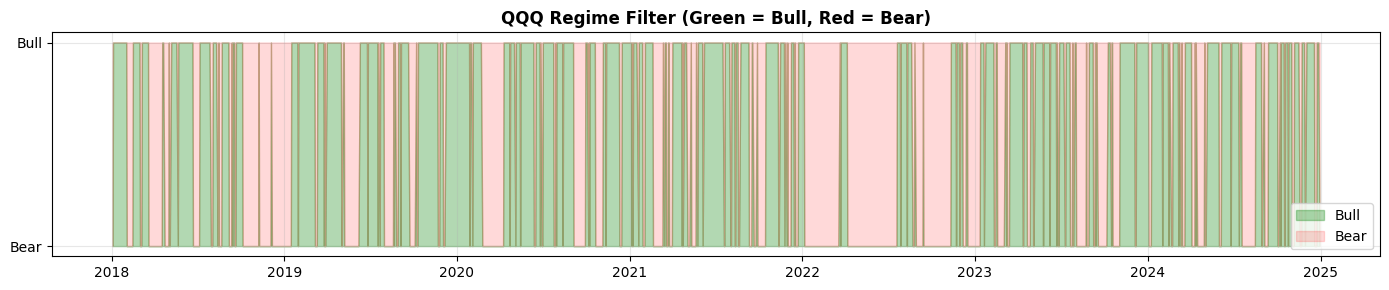

Saved → /Users/aaravaguru/Library/CloudStorage/OneDrive-IndianaUniversity/Quant Project 1 - DriftFIre/reports/figures/regime_filter.png


In [3]:
# ============================================================
# CELL 3 — QQQ Regime Filter
# ============================================================
# WHAT THIS DOES:
#   The creator's rule: only open new longs when QQQ is above
#   its 8, 21, AND 50 EMA simultaneously. If QQQ breaks below
#   ANY of these, regime = bearish → sit on hands.
#
#   Uses shifted (prior-day) QQQ data to stay consistent with
#   the no-lookahead framework from notebook 01.
#
# WHAT YOU SHOULD SEE:
#   % of trading days in bull vs bear regime. Expect roughly
#   60-70% bull days over 2018-2024. The bear periods should
#   align with known selloffs (Q4 2018, Mar 2020, 2022).
# ============================================================
 
# --- extract QQQ rows ---
qqq = df[df["ticker"] == REGIME_TICKER][["date", "prev_close", "prev_ema8", "prev_ema21", "prev_ema50"]].copy()
qqq = qqq.dropna(subset=["prev_close", "prev_ema8", "prev_ema21", "prev_ema50"])
 
# --- regime: QQQ close above ALL three EMAs ---
qqq["regime_bull"] = (
    (qqq["prev_close"] > qqq["prev_ema8"]) &
    (qqq["prev_close"] > qqq["prev_ema21"]) &
    (qqq["prev_close"] > qqq["prev_ema50"])
)
 
# --- create date-level lookup ---
regime_lookup = qqq.set_index("date")["regime_bull"]
 
# --- merge into main df ---
df["regime_bull"] = df["date"].map(regime_lookup)
 
# --- stats ---
bull_days = regime_lookup.sum()
total_days = len(regime_lookup)
bear_days = total_days - bull_days
 
print(f"REGIME FILTER (QQQ above 8/21/50 EMA)")
print(f"{'='*50}")
print(f"  Bull days : {bull_days:,} ({bull_days/total_days*100:.1f}%)")
print(f"  Bear days : {bear_days:,} ({bear_days/total_days*100:.1f}%)")
print(f"  Total     : {total_days:,}")
 
# --- quick visual: regime over time ---
fig, ax = plt.subplots(figsize=(14, 3))
regime_ts = regime_lookup.astype(int)
ax.fill_between(regime_ts.index, regime_ts.values, alpha=0.3, color="green", label="Bull")
ax.fill_between(regime_ts.index, regime_ts.values, 1, alpha=0.15, color="red", label="Bear")
ax.set_title("QQQ Regime Filter (Green = Bull, Red = Bear)", fontsize=12, fontweight="bold")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Bear", "Bull"])
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "regime_filter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'regime_filter.png'}")
 


SECTOR ROTATION FILTER
  Avg hot sectors per day  : 0.8
  Days with 0 hot sectors  : 627
  Days with 1+ hot sectors : 953
  Max hot sectors in a day : 3


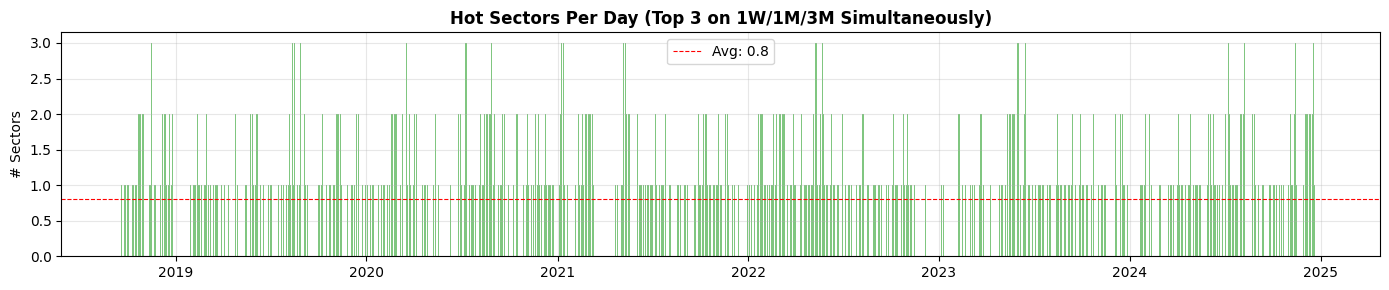

Saved → /Users/aaravaguru/Library/CloudStorage/OneDrive-IndianaUniversity/Quant Project 1 - DriftFIre/reports/figures/sector_rotation.png


In [4]:
# ============================================================
# CELL 4 — Sector Rotation Ranking
# ============================================================
# WHAT THIS DOES:
#   Replicates the creator's manual Finviz Groups tab process:
#   1. For each of the 11 SPDR sector ETFs, compute rolling
#      returns over 1-week (5d), 1-month (21d), 3-month (63d).
#   2. Rank all 11 sectors on each timeframe (1 = best).
#   3. A sector is "hot" only if it ranks in the top 3 on ALL
#      THREE timeframes simultaneously.
#   4. Map each stock to its sector and flag sector_hot.
#
#   Uses shifted data (returns as of prior day's close).
#
# WHAT YOU SHOULD SEE:
#   Average number of hot sectors per day (typically 1-3).
#   A heatmap showing which sectors were hot over time.
# ============================================================
 
# --- extract ETF data ---
etf_data = df[df["ticker"].isin(SECTOR_ETFS)][["date", "ticker", "close"]].copy()
etf_data = etf_data.sort_values(["ticker", "date"])
 
# --- compute rolling returns per ETF ---
def compute_returns(group):
    g = group.sort_values("date").copy()
    g["ret_1w"] = g["close"].pct_change(ROTATION_1W)
    g["ret_1m"] = g["close"].pct_change(ROTATION_1M)
    g["ret_3m"] = g["close"].pct_change(ROTATION_3M)
    return g
 
etf_data = etf_data.groupby("ticker", group_keys=False).apply(compute_returns)
 
# --- shift by 1 day (no lookahead) ---
for col in ["ret_1w", "ret_1m", "ret_3m"]:
    etf_data[f"prev_{col}"] = etf_data.groupby("ticker")[col].shift(1)
 
# --- pivot: date × ETF → returns ---
ret_cols = ["prev_ret_1w", "prev_ret_1m", "prev_ret_3m"]
periods = {"prev_ret_1w": "rank_1w", "prev_ret_1m": "rank_1m", "prev_ret_3m": "rank_3m"}
 
# rank sectors on each date for each timeframe
# lower rank = better (rank 1 = highest return)
hot_sectors_by_date = {}
 
for date_val, day_group in etf_data.groupby("date"):
    day_group = day_group.dropna(subset=ret_cols)
    if len(day_group) < len(SECTOR_ETFS):
        continue  # not all ETFs have data yet (warmup period)
 
    rankings = {}
    for ret_col, rank_col in periods.items():
        ranked = day_group[["ticker", ret_col]].copy()
        ranked[rank_col] = ranked[ret_col].rank(ascending=False, method="min")
        rankings[rank_col] = dict(zip(ranked["ticker"], ranked[rank_col]))
 
    # a sector is "hot" if rank <= TOP_N in ALL three timeframes
    hot = []
    for etf in SECTOR_ETFS:
        r1w = rankings["rank_1w"].get(etf, 99)
        r1m = rankings["rank_1m"].get(etf, 99)
        r3m = rankings["rank_3m"].get(etf, 99)
        if r1w <= TOP_N_SECTORS and r1m <= TOP_N_SECTORS and r3m <= TOP_N_SECTORS:
            hot.append(etf)
 
    hot_sectors_by_date[date_val] = set(hot)
 
# --- build date-level hot sector lookup ---
hot_sector_df = pd.DataFrame([
    {"date": d, "hot_sectors": s} for d, s in hot_sectors_by_date.items()
])
hot_sector_df["n_hot"] = hot_sector_df["hot_sectors"].apply(len)
 
# --- map to stocks: is this stock's sector hot today? ---
def check_sector_hot(row):
    if pd.isna(row["sector_etf"]):
        return False
    hot = hot_sectors_by_date.get(row["date"], set())
    return row["sector_etf"] in hot
 
df["sector_hot"] = df.apply(check_sector_hot, axis=1)
 
# --- stats ---
avg_hot = hot_sector_df["n_hot"].mean()
print(f"SECTOR ROTATION FILTER")
print(f"{'='*50}")
print(f"  Avg hot sectors per day  : {avg_hot:.1f}")
print(f"  Days with 0 hot sectors  : {(hot_sector_df['n_hot'] == 0).sum()}")
print(f"  Days with 1+ hot sectors : {(hot_sector_df['n_hot'] > 0).sum()}")
print(f"  Max hot sectors in a day : {hot_sector_df['n_hot'].max()}")
 
# --- quick visual ---
fig, ax = plt.subplots(figsize=(14, 3))
ts = hot_sector_df.set_index("date")["n_hot"].sort_index()
ax.bar(ts.index, ts.values, width=1, color="#2ca02c", alpha=0.6)
ax.set_title("Hot Sectors Per Day (Top 3 on 1W/1M/3M Simultaneously)", fontsize=12, fontweight="bold")
ax.set_ylabel("# Sectors")
ax.axhline(y=avg_hot, color="red", linestyle="--", linewidth=0.8, label=f"Avg: {avg_hot:.1f}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "sector_rotation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'sector_rotation.png'}")
 


KeyError: 'prev_volume'